# Introduzione

## Obiettivo della misura

In questo notebook è descritta una procedura per l'analisi dei dati raccolti dal telescopio muonico della metropolitana di Toledo a Napoli.
In particolare, viene descritto come è possibile ricostruire la traccia dei muoni che attraversano il rivelatore al fine di confrontare la distribuzione di raggi cosmici misurata con quella teorica ottenuta utilizzando un semplice modello.

## Strumentazione

Lo strumento di misura consiste in un telescopio di raggi cosmici costituito da dieci piani di bacchette di materiale scintillante plastico che produce un debole impulso di luce quando attraversato da particelle cariche. In particolare, per ogni piano troviamo disposte ortogonalmente tra loro (a scacchiera) venti barre che individuano le direzioni $x$ e $y$ del rivelatore. Ciascuna bacchetta misura $4 \times 40 \times 1 \, cm^3$ ed è accoppiato con una fibra ottica (WLS) ed un fotomoltiplicatore al silicio (SiPM). I piani sono distanziati tra loro di $7 \, cm$.

# Analisi dati

I dati analizzati si riferiscono all'anno 2016 e sono scaricabili dal seguente [link](https://people.na.infn.it/~totem/Eventi/).

In [4]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from matplotlib import gridspec
import statsmodels.stats.proportion as proportion
import math

## Decodifica dei dati

Ciascun file *raw* è costituito da triplette di righe e per ciascuna di esse la prima riga contiene l'identificativo dell'evento (in esadecimale); la seconda e la terza contengono entrambe una stringa di 30 cifre in esadecimale  che rappresentano rispettivamente la vista *Slave* ($YZ$) e la vista *Master* ($XZ$) del telescopio. Ciascuna stringa contiene 10 triplette di cifre che rappresentano l'informazione di un piano del telescopio. Il primo piano dal basso corrisponde alla prima tripletta da sinistra. Traducendo queste triplette in binario, si ottiene una rappresentazione in *bit* della traccia lasciata all'interno del telescopio dalla particella. Introducendo un sistema di coordinate cartesiane, è possibile misurare gli angoli $\theta_x$, $\theta_y$ che la traccia forma con la verticale rispettivamente nei piani $XZ$ e $YZ$ tramite le pendenze delle rette di *best-fit*: $x = m_x z + q_x$ e  $y = m_y z + q_y$.

In [12]:
events = []
for m in range(9, 13):
    for d in range(1, 32):
        if m<10 and d<10:
            fp = 'Eventi/Muoni_Eventi_2016_0{}_0{}.txt'.format(m, d)
        elif m<10 and d>=10:
            fp = 'Eventi/Muoni_Eventi_2016_0{}_{}.txt'.format(m, d)
        elif m>=10 and d<10:
            fp = 'Eventi/Muoni_Eventi_2016_{}_0{}.txt'.format(m, d)
        elif m>=10 and d>=10:
            fp = 'Eventi/Muoni_Eventi_2016_{}_{}.txt'.format(m, d)
        events.append(fp)

In [41]:
evts_bin = []
for file in events:
    try:
        data = open(file, 'r')
        raw = data.readlines()
        lines = [raw[i:i+3] for i in range(0, len(raw)-2, 3)]
        for line in lines:
            master, slave = line[2], line[1]
            x_hex = [master[i:i+3] for i in range(0, len(master)-2, 3)]
            y_hex = [slave[i:i+3] for i in range(0, len(slave)-2, 3)]
            x_bin = [f'{int(x,16):0>12b}' for x in x_hex]
            y_bin = [f'{int(y,16):0>12b}' for y in y_hex]
            evts_bin.append(np.array([x_bin, y_bin]))
    except: None
evts_bin = np.array(evts_bin)

In [43]:
d = 4
master, slave = evts_bin[:,0], evts_bin[:,1]
def bin_to_cartesian(a, d):
    X = []
    for e in a:
        track = []
        for i in range(10):
            num, den = 0, 0
            for j in range(10):
                num += int(e[i][j+2])*(2 + j*d)
                den += int(e[i][j+2])
            try: x = num/den
            except: x = np.nan
            finally: track.append(x)
        X.append(track)
    return X
xz = bin_to_cartesian(master, d)
yz = bin_to_cartesian(slave, d)

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
def vertical_angle(a, maxerr, h):
    z = pd.Series([h*j for j in range(10)], index = a.index)
    y = a[np.isfinite(a)]
    x = z[np.isfinite(a)]
    def slope(x, y):
        N = x.size
        if N<=2:
            return np.nan, np.nan
        elif N>2:
            cov = (x*y).mean() - x.mean()*y.mean()
            m = cov/x.var(ddof=0)
            q = y.mean() - m*x.mean()
            y_fit = m*x+np.full(N, q)
            mse = ((y-y_fit)**2).mean()
            sigma = np.sqrt(mse/(N-2))
            if sigma<maxerr:
                merr = sigma/np.sqrt(N)/x.std(ddof=0)
                return m, merr
            else:
                merr = maxerr/np.sqrt(N)/x.std(ddof=0)
                return m, merr
    m, merr = slope(x, y)
    theta, err = np.arctan(m), merr/(1+m**2)
    return theta, err

In [ ]:
XZ = pd.DataFrame(xz, columns = ['x{:}'.format(n) for n in range(10)])
YZ = pd.DataFrame(yz, columns = ['y{:}'.format(n) for n in range(10)])
h = 7
maxerr = 2
theta_x = np.array([vertical_angle(row, maxerr, h) for _,row in XZ.iterrows()])
theta_y = np.array([vertical_angle(row, maxerr, h) for _,row in YZ.iterrows()])
th_x, err_x = theta_x[:,0], theta_x[:,1]
th_y, err_y = theta_y[:,0], theta_y[:,1]
data16 = pd.DataFrame({'theta_x': th_x, 'err_x': err_x, 'theta_y': th_y, 'err_y':err_y})
data16.to_csv('data16')

## Stima di $\Delta T$

Osservando la distribuzione temporale degli eventi per ciascun giorno con bin di 30 secondi, è ragionevole supporre che la macchina sia stata accesa per tutto il tempo di un giorno a partire dalla prima fino all'ultima misura di un evento.

In [4]:
datetimes = []
for m in range(9, 13):
    for d in range(1, 32):
        if m<10 and d<10:
            fp = 'Eventi/Muoni_Orario_2016_0{}_0{}.txt'.format(m, d)
        elif m<10 and d>=10:
            fp = 'Eventi/Muoni_Orario_2016_0{}_{}.txt'.format(m, d)
        elif m>=10 and d<10:
            fp = 'Eventi/Muoni_Orario_2016_{}_0{}.txt'.format(m, d)
        elif m>=10 and d>=10:
            fp = 'Eventi/Muoni_Orario_2016_{}_{}.txt'.format(m, d)
        datetimes.append(fp)

In [6]:
durations = []
for file in datetimes:
    try:
        temp = pd.read_table(file, sep = r'\s+', names = ['event_id','time','theta_x','theta_y'])
        time = pd.to_timedelta(temp.time)
        timemin, timemax = time.min(), time.max()
        deltatime = timemax - timemin
        durations.append(deltatime.total_seconds())
    except:
        None
t_tot = round(pd.Series(durations).sum()/60, 0)
print('Δt = ', t_tot, 'min')

AttributeError: 'int' object has no attribute 'total_seconds'

## Misura dell'efficienza del rivelatore

In [ ]:
def errorcount(view, h, l):
    expected, dead, hot = np.zeros(10), np.zeros(10), np.zeros(10)
    z = pd.Series([h*j for j in range(10)], index = view.columns)
    for _,row in view.iterrows():
        y = row[np.isfinite(row)]
        x = z[np.isfinite(row)]
        N = x.size
        if N>2:
            cov = (x*y).mean() - x.mean()*y.mean()
            m = cov/x.var(ddof=0)
            q = y.mean() - m*x.mean()
            row_fit = m*z+np.full(10, q)
            exp = (row_fit>0) & (row_fit<l)
            hit = (row>0) & (row<l)
            d = (exp==1) & (hit==0)
            h = (exp==0) & (hit==1)
            expected+=exp
            dead+=d
            hot+=h
    return expected, dead, hot

In [ ]:
XZ = pd.read_csv('master16')
YZ = pd.read_csv('slave16')
h, l = 7, 40
exp_x, dead_x, hot_x = errorcount(XZ, h, l)
exp_y, dead_y, hot_y = errorcount(YZ, h, l)
N_x, n_x, = exp_x.sum(), dead_x.sum()
N_y, n_y, = exp_y.sum(), dead_y.sum()
eff_x = (N_x - n_x)/N_x
err_x = np.sqrt(eff_x*(1-eff_x)/N_x)
eff_y = (N_y - n_y)/N_y
err_y = np.sqrt(eff_y*(1-eff_y)/N_y)
print('eff_x = {:.04f} +/- {:.04f}'.format(eff_x,err_x))
print('eff_y = {:.04f} +/- {:.04f}'.format(eff_y,err_y))

## Distribuzioni sperimentali

Gli angoli misurati $\theta_x$ e $\theta_y$ variano in $[-\frac{\pi}{2}, \frac{\pi}{2}]$ si riferiscono agli angoli che le proiezioni della traccia sui piani coordinati $XZ$ (vista *master*) e $YZ$ (vista *slave*) formano con la verticale. La trasformazione che consente di passare agli angoli polari è la seguente:
\begin{cases}
\theta = \arccos \left( \frac{1}{\sqrt{m_x^2 + m_y^2 + 1}}\right) \\
\varphi = \arctan \left( \frac{m_y}{m_x}\right)
\end{cases}
dove $m_{x,y} = \tan (\theta_{x,y})$ e l'arcotangente è calcolata in modo da assegnare ad ogni coppia di angoli il corretto angolo in $[0, 2\pi]$ .

Secondo il modello più comuni, la distribuzione angolare di raggi cosmici è data da

$\displaystyle f_{\theta, \varphi}(\theta, \varphi) = \frac{n+1}{2\pi}{\cos}^n\theta \sin \theta$

dove $\theta \in [0, \pi/2]$, $\varphi \in [0, 2\pi]$ e tipicamente $n=2$.

Applicando le regole di trasformazione delle variabili casuali, otteniamo la distribuzione per  $\theta_x$ e $\theta_y$:

$\displaystyle f_{\theta_x, \theta_y}(\theta_x, \theta_y) = \frac{n+1}{2\pi} \frac{1}{{\left({\tan}^2\theta_x + {\tan}^2\theta_y + 1 \right)}^{\left(n+3\right)/2} \, {\cos}^2 \theta_x {\cos}^2 \theta_y}$.

In [6]:
df = pd.read_csv('data16')
th_x, err_x = df.theta_x, df.err_x
th_y, err_y = df.theta_y, df.err_y

Escludiamo le tracce perfettamente verticale, in quanto portano problemi nel calcolo dell'angolo $\phi$.

In [8]:
th_x = th_x[(th_x!=0) & (th_y!=0)]
th_y = th_y[(th_x!=0) & (th_y!=0)]

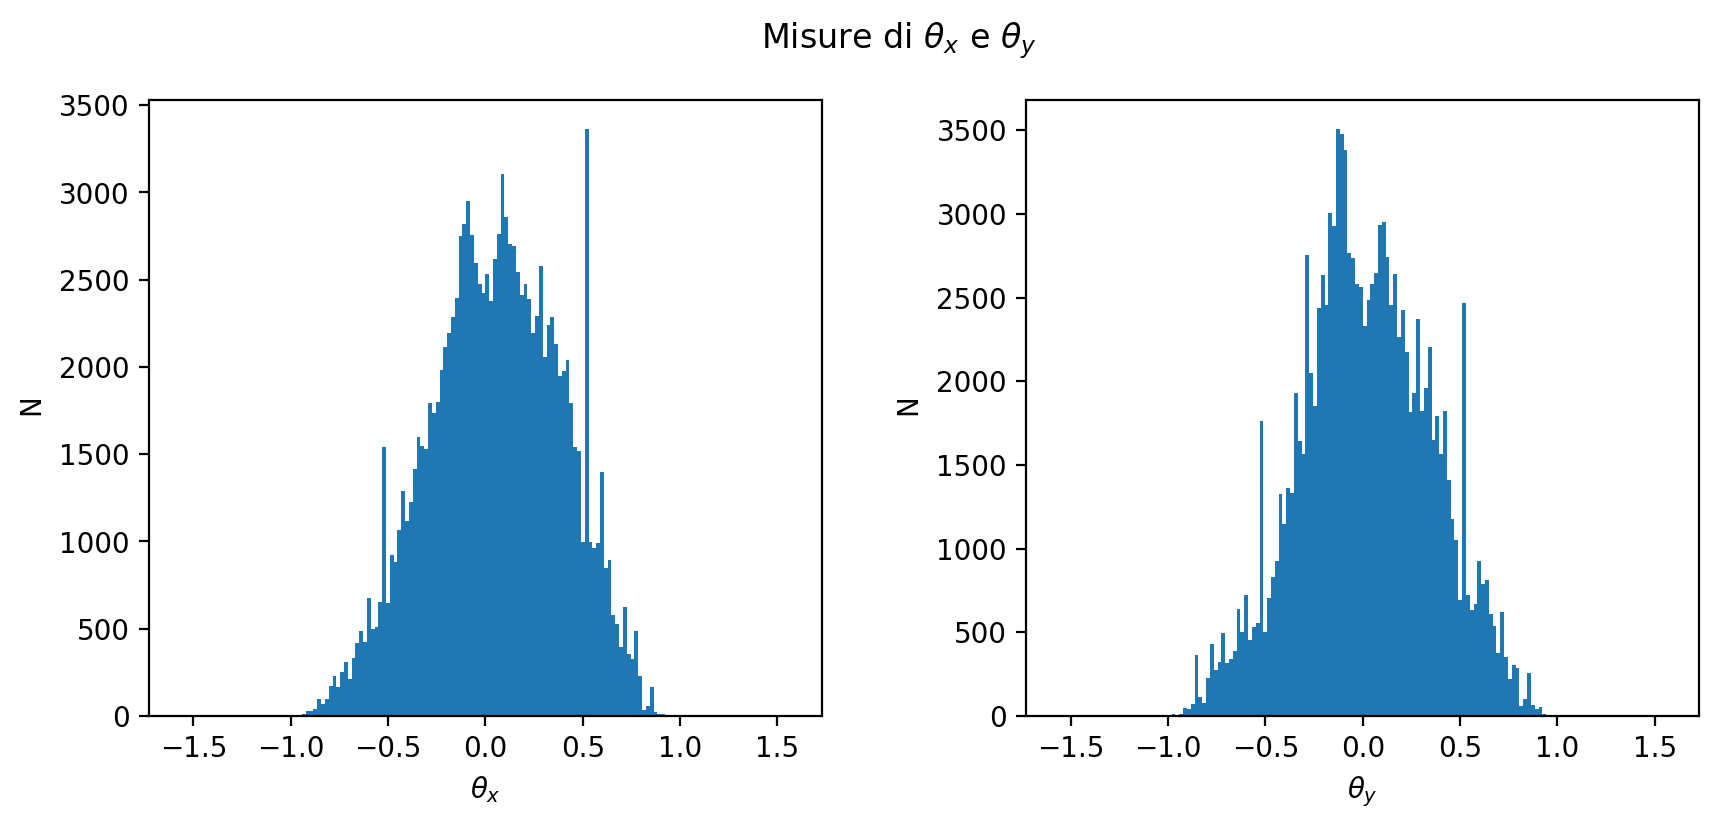

In [10]:
fig = plt.figure(figsize = (10, 4), dpi=200)
gs = gridspec.GridSpec(1, 9)
ax0 = fig.add_subplot(gs[:, :4])
ax1 = fig.add_subplot(gs[:, 5:])
m = 2
nbins1 = int(m*80)
th_range = (-math.pi/2, math.pi/2)
n_x, bins_x, _ = ax0.hist(th_x, bins=nbins1, density=False, range=th_range)
ax0.set_xlabel(r'$\theta_x$')
ax0.set_ylabel(r'$\mathrm{N}$')
n_y, bins_y, _ = ax1.hist(th_y, bins=nbins1, density=False, range=th_range)
ax1.set_xlabel(r'$\theta_y$')
ax1.set_ylabel(r'$\mathrm{N}$')
plt.suptitle(r'Misure di $\theta_x$ e $\theta_y$')
plt.show()

In [12]:
mx = np.tan(th_x)
my = np.tan(th_y)
th_m = np.arccos(1/np.sqrt(mx**2+my**2+1))
ph_m = np.arctan2(my, mx)+np.pi

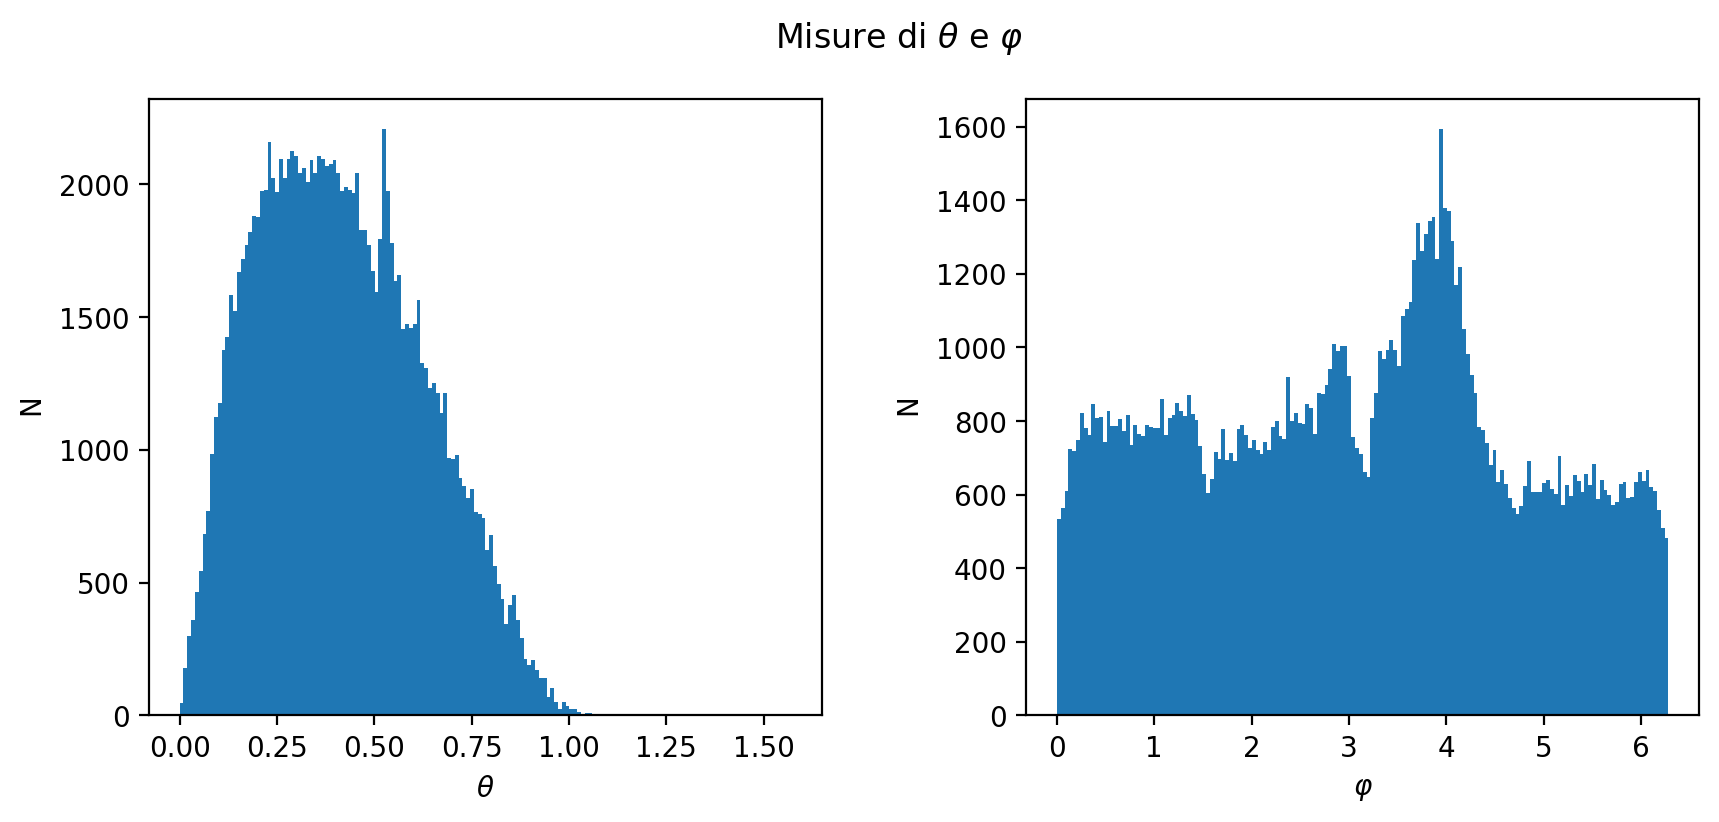

In [14]:
fig = plt.figure(figsize = (10, 4), dpi=200)
gs = gridspec.GridSpec(1, 9)
ax0 = fig.add_subplot(gs[:, :4])
ax1 = fig.add_subplot(gs[:, 5:])
th_range = (0, math.pi/2)
n_th_m, bins_th, _ = ax0.hist(th_m, bins=nbins1, density=False, range=th_range)
ax0.set_xlabel(r'$\theta$')
ax0.set_ylabel(r'$\mathrm{N}$')
ph_range = (0, 2*math.pi)
n_ph_m, bins_ph, _ = ax1.hist(ph_m, bins=nbins1, density=False, range=ph_range)
ax1.set_xlabel(r'$\varphi$')
ax1.set_ylabel(r'$\mathrm{N}$')
plt.suptitle(r'Misure di $\theta$ e $\varphi$')
plt.show()

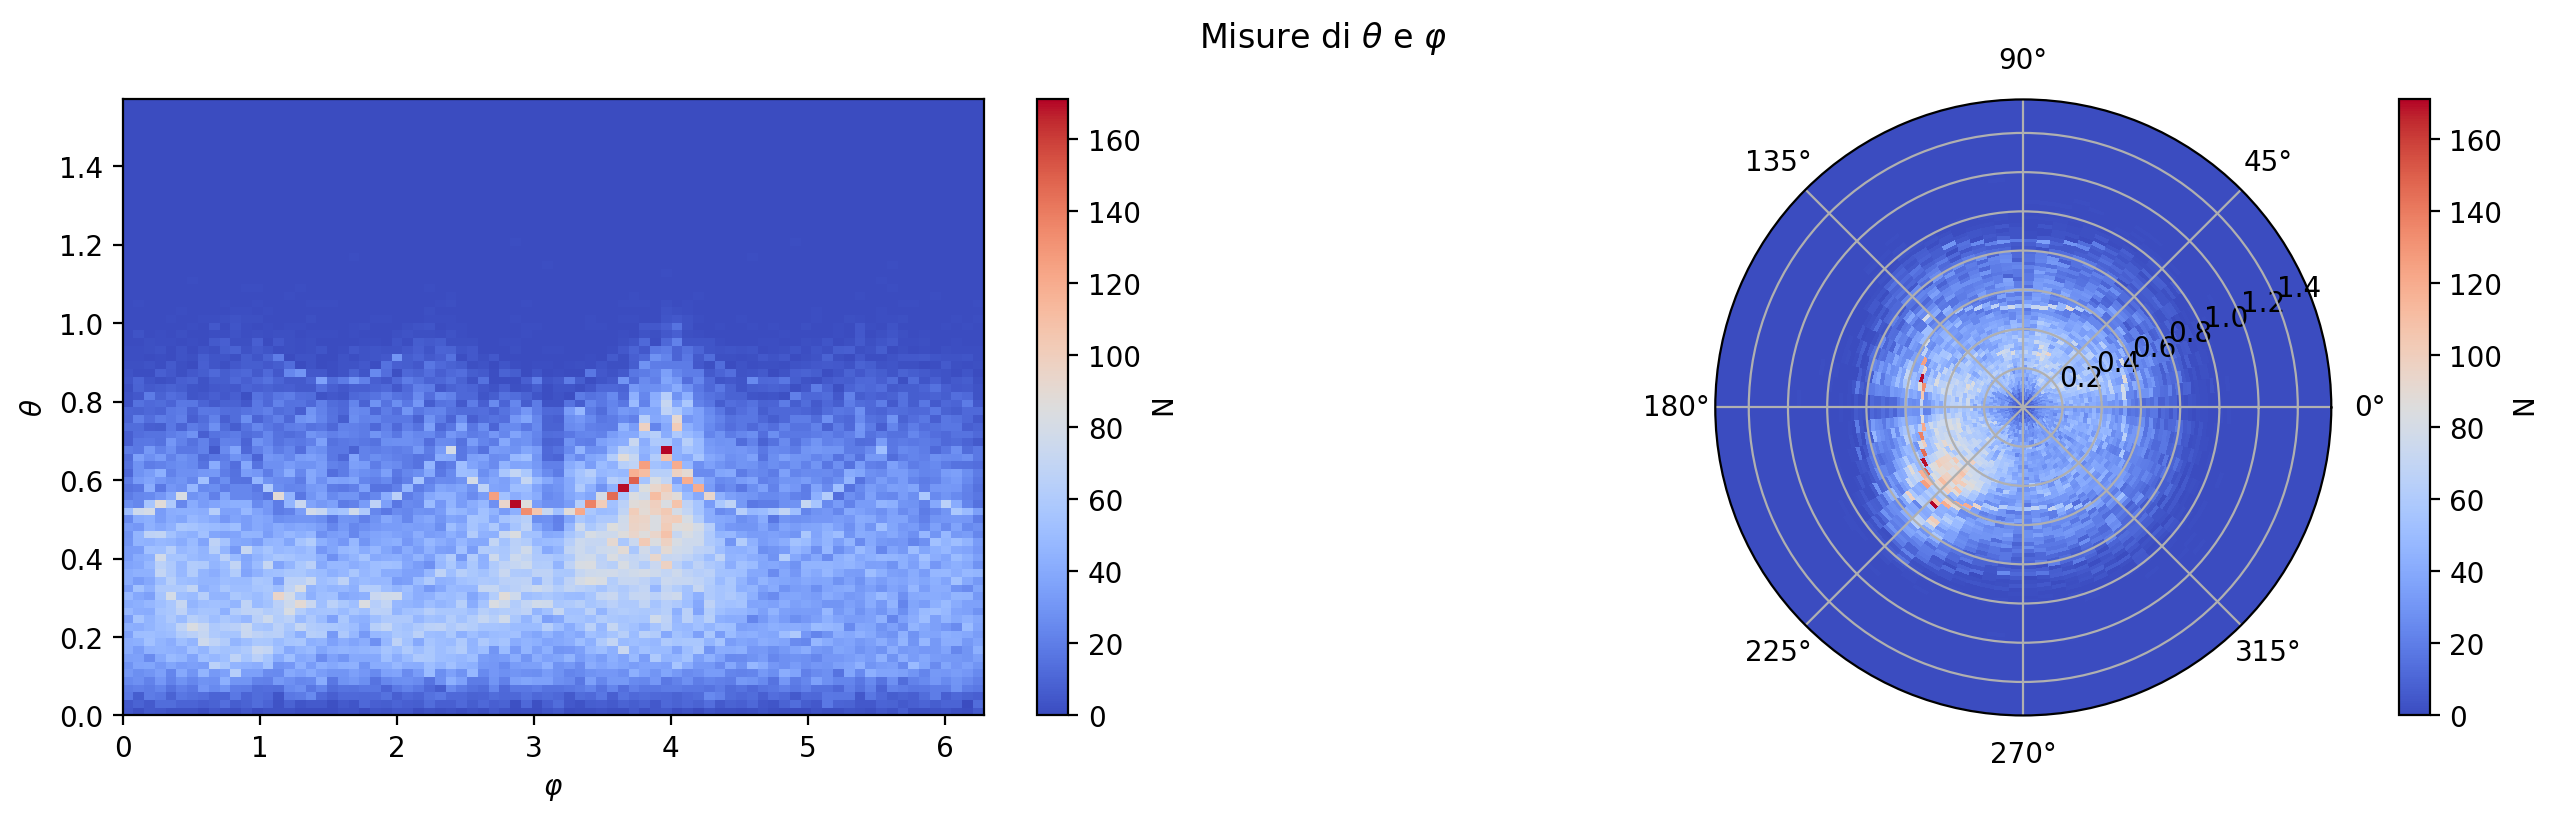

In [16]:
fig = plt.figure(figsize = (16, 4), dpi=200)
gs = gridspec.GridSpec(1, 9)
ax0 = fig.add_subplot(gs[:, :4])
ax1 = fig.add_subplot(gs[:, 4:], projection='polar')
nbins2 = int(m*40)

h_m, phi_edges, theta_edges, im0 = ax0.hist2d(ph_m, th_m, nbins2, range = (ph_range, th_range), density = False, cmap = 'coolwarm')
fig.colorbar(im0, ax = ax0, label = r'$\mathrm{N}$')
ax0.set(xlabel = r'$\varphi$', ylabel = r'$\theta$')

_, _, _, im1 = ax1.hist2d(ph_m, th_m, nbins2, density = False, range = (ph_range, th_range), cmap = 'coolwarm')
fig.colorbar(im1, ax = ax1, label = r'$\mathrm{N}$')

plt.suptitle(r'Misure di $\theta$ e $\varphi$')
plt.show()

## Distribuzione teorica Monte Carlo

La trasmissione $T$ è definita come il rapporto tra numero misurato di muoni sottoterra e il numero atteso di muoni in un esperimento a cielo aperto:

$\displaystyle T = \frac{N^{u}}{N^{fs}}$.

$N^{fs}$ è pari al flusso di muoni integrato su energia, tempo, superficie e angolo solido.
Richiedendo che almeno su sei piani del telescopio ci sia un LED acceso, si ottiene una *rate* di 4 eventi al minuto. Possiamo stimare $N^{fs}$ più semplicemente come:

$\displaystyle N^{fs} = S \cdot \Delta t \cdot r$.

Il numero minimo di segnali richiesto per identificare una correlazione è tre, in quanto questi servono per un *fit* lineare. Il campo visivo del telescopio in termini di $\theta_x$ e $\theta_y$ si ottiene quindi immaginando di osservare una risposta da tre piani consecutivi, che corrisponde a un'apertura massima rispetto allo zenith di $arctan(40/21)\approx 62^{\circ}$, in accordo con i dati. L'area su cui generare i punti di impatto dei raggi cosmici è pertanto definita dalla proporzione $20:14=L/2:63$, cioè $L=320 \, cm$.

In [21]:
L = 320 # l'area su cui genero i punti di impatto dei raggi cosmici
n_mc = 500000 # numero di raggi cosmici generato
l = 40 # lato del rivelatore
h = 7 # distanza tra i piani
n_p = 10 # numero di piani
beta = 2
n_hit = 0
np.random.seed(1234)
theta_hit, phi_hit = [], []
theta = np.arccos((1 - np.random.uniform(size = n_mc))**(1/(beta+1)))
phi = 2*math.pi*np.random.uniform(size = n_mc)
st, ct, sp, cp = np.sin(theta), np.cos(theta), np.sin(phi), np.cos(phi)
us, vs, ws = st*cp, st*sp, ct
x0s = np.random.uniform(-L/2, L/2, size = n_mc)
y0s = np.random.uniform(-L/2, L/2, size = n_mc)
x1s = np.array([[x0 + (j*h)*(u/w) for j in range(n_p)] for x0, u, w in zip(x0s, us, ws)])
y1s = np.array([[y0 + (j*h)*(v/w) for j in range(n_p)] for y0, v, w in zip(y0s, vs, ws)])
hits = [((x>-l/2) & (x<l/2) & (y>-l/2) & (y<l/2)) for x, y in zip(x1s, y1s)]
for hit, th, ph in zip(hits, theta, phi):
    led = True
    for i in range(0,5):
        if not any(hit[i:i+6]):
            led = False
    if led:
        n_hit+=1
        theta_hit.append(th)
        phi_hit.append(ph)        
print("{:d}/{:d}".format(n_hit, n_mc))
eff = n_hit/(n_mc)
err = np.sqrt(eff*(1 - eff)/n_mc)
print("ε = {:.4f}±{:.4f}".format(eff, err))

9141/500000
ε = 0.0183±0.0002


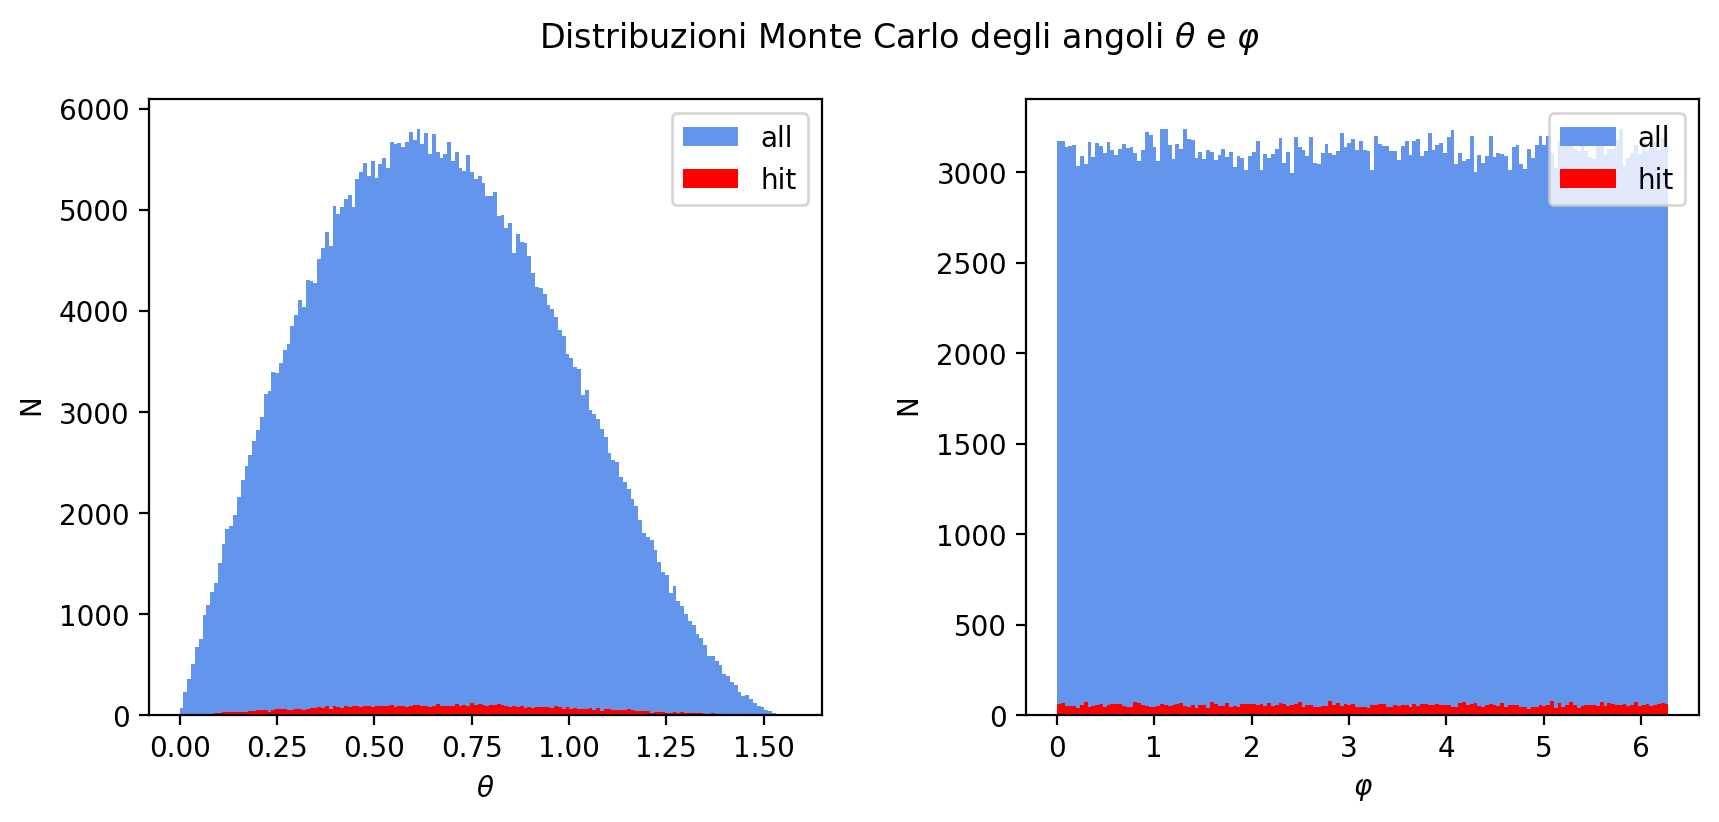

In [22]:
fig = plt.figure(figsize = (10, 4), dpi=200)
gs = gridspec.GridSpec(1, 9)
ax0 = fig.add_subplot(gs[:, :4])
ax1 = fig.add_subplot(gs[:, 5:])


n_th_t, _, _ = ax0.hist(theta, density=False, bins=nbins1, range=th_range, color='cornflowerblue', label='all')
n_th_h, _, _ = ax0.hist(theta_hit, density=False, bins=nbins1, range=th_range, color='red', label='hit')
ax0.set(xlabel=r'$\theta$', ylabel=r'$\mathrm{N}$')
ax0.legend()


n_ph_t, _, _ = ax1.hist(phi, density=False, bins=nbins1, range=ph_range, color='cornflowerblue', label='all')
n_ph_h, _, _ = ax1.hist(phi_hit, density=False, bins=nbins1, range=ph_range, color='red', label='hit')
ax1.set(xlabel=r'$\varphi$', ylabel=r'$\mathrm{N}$')
ax1.legend()

plt.suptitle(r'Distribuzioni Monte Carlo degli angoli $\theta$ e $\varphi$')
plt.show()

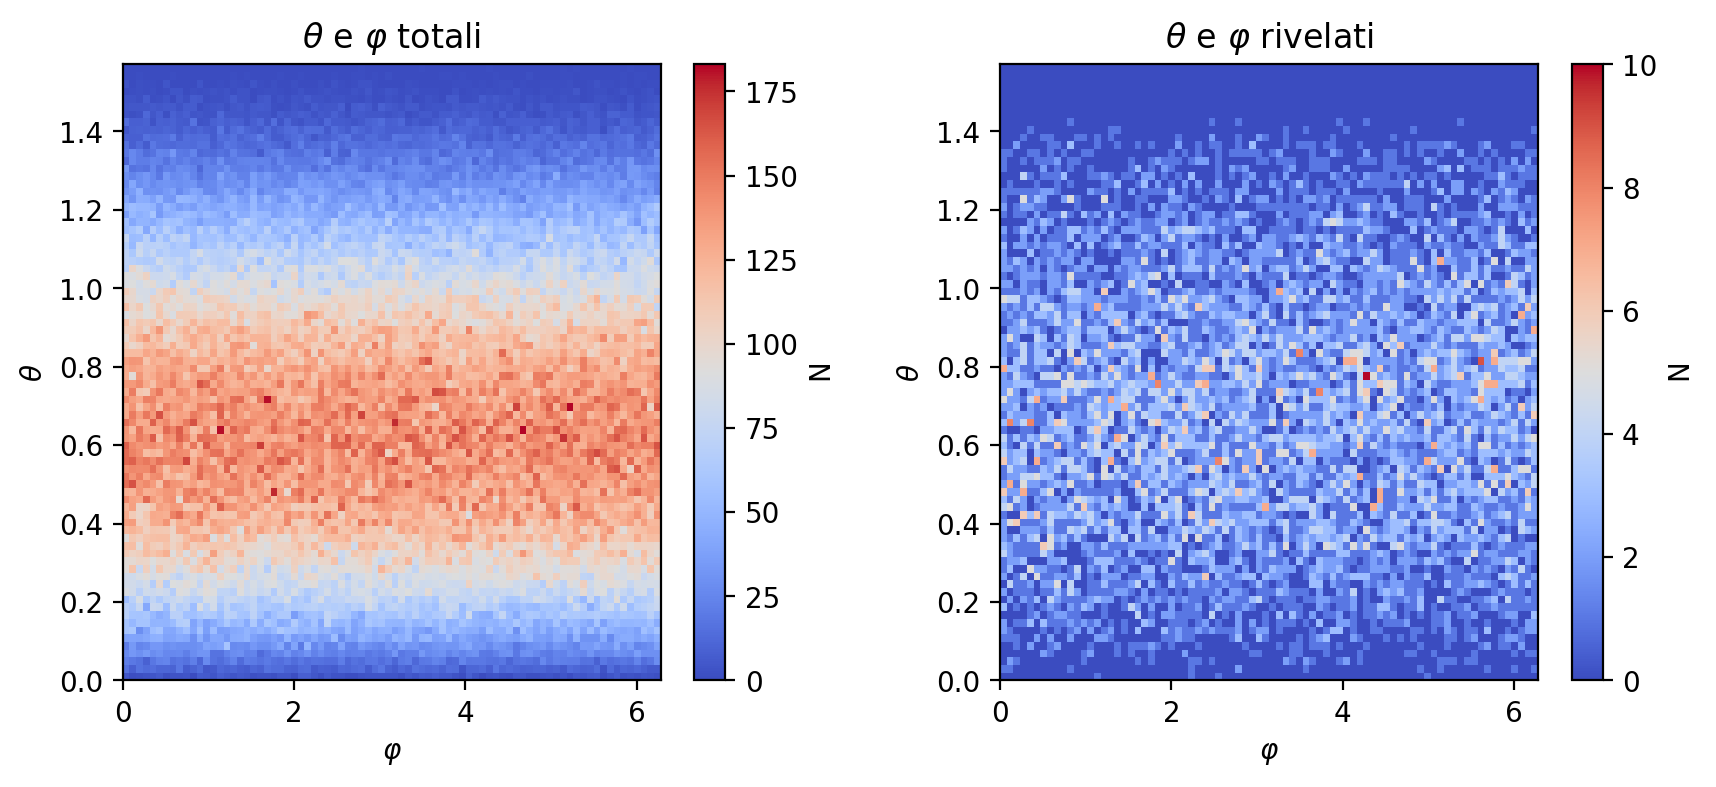

In [23]:
fig = plt.figure(figsize = (10, 4), dpi=200)
gs = gridspec.GridSpec(1, 9)
ax0 = fig.add_subplot(gs[:, :4])
ax1 = fig.add_subplot(gs[:, 5:])

h_t, phi_edges, theta_edges, im0 = ax0.hist2d(phi, theta, nbins2, range = (ph_range, th_range), density = False, cmap = 'coolwarm')
fig.colorbar(im0, ax = ax0, label = r'$\mathrm{N}$')
ax0.set(xlabel = r'$\varphi$', ylabel = r'$\theta$', title = r'$\theta$ e $\varphi$ totali')

h_h, phi_edges, theta_edges, im1 = ax1.hist2d(phi_hit, theta_hit, nbins2, range = (ph_range, th_range), density = False, cmap = 'coolwarm')
fig.colorbar(im1, ax = ax1, label = r'$\mathrm{N}$')
ax1.set(xlabel = r'$\varphi$', ylabel = r'$\theta$', title = r'$\theta$ e $\varphi$ rivelati')

plt.show()

In [24]:
th1, ph1 = (bins_th[1:]+bins_th[:-1])/2, (bins_ph[1:]+bins_ph[:-1])/2
delta_th1 = bins_th[1] - bins_th[0]
delta_ph1 = bins_ph[1] - bins_ph[0]
a_th = np.divide(n_th_h, n_th_t, out=np.zeros_like(n_th_t), where=n_th_t != 0)
a_ph = np.divide(n_ph_h, n_ph_t, out=np.zeros_like(n_ph_t), where=n_ph_t != 0)
ph2, th2 = (phi_edges[1:]+phi_edges[:-1])/2, (theta_edges[1:]+theta_edges[:-1])/2
delta_th2 = theta_edges[1] - theta_edges[0]
delta_ph2 = phi_edges[1] - phi_edges[0]
a_th_ph = np.divide(h_h, h_t, out=np.zeros_like(h_t), where=h_t!=0)

In [25]:
t_tot = 104372 #min
r = 4 #muon/min/cm2
N_fs = t_tot*r*(L/100)**2
print('N_fs = ', N_fs)

N_fs =  4275077.120000001


In [26]:
def model_th(x, beta):
    return 3*np.sin(x)*np.cos(x)**beta
f_th = model_th(th1, beta)
c_th = (f_th*a_th).sum()*delta_th1
c_ph = (a_ph/2/math.pi).sum()*delta_ph1
N_fs_th = N_fs*delta_th1*a_th*f_th/c_th
N_fs_ph = N_fs*delta_ph1*a_ph/2/math.pi/c_ph

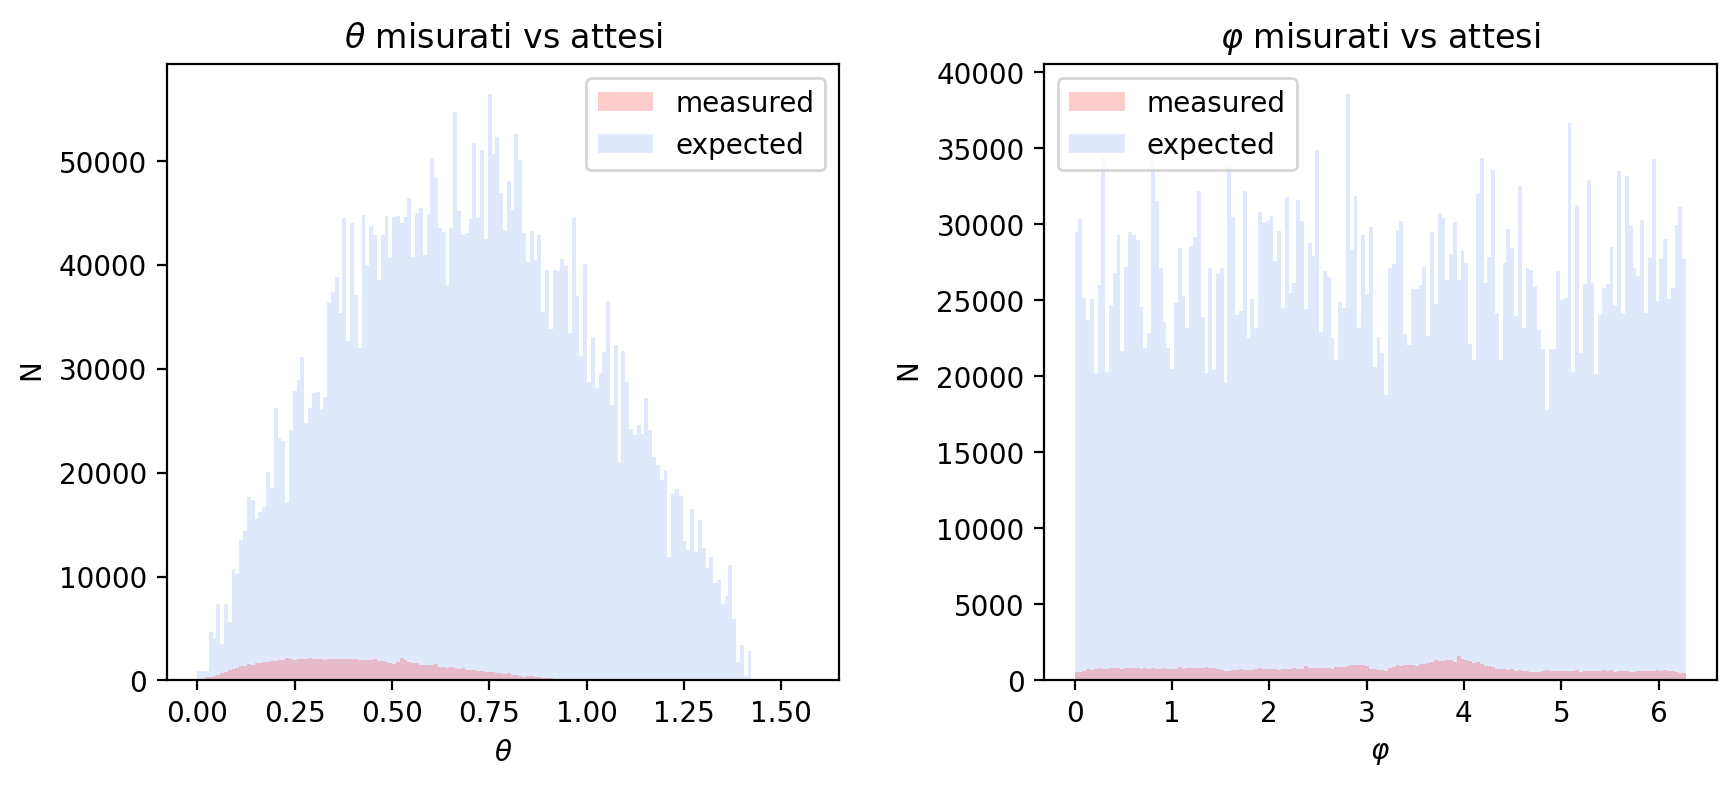

In [27]:
fig = plt.figure(figsize = (10, 4), dpi=200)
gs = gridspec.GridSpec(1, 9)
ax0 = fig.add_subplot(gs[:, :4])
ax1 = fig.add_subplot(gs[:, 5:])

ax0.bar(th1, N_fs_th, width = delta_th1, bottom=0, align='center', color='cornflowerblue', label='expected', alpha=0.2)
ax0.hist(th_m, density=False, bins=nbins1, range=th_range, color='red', label='measured', alpha=0.2)
ax0.set(xlabel=r'$\theta$', ylabel=r'$\mathrm{N}$', title=r'$\theta$ misurati vs attesi')
ax0.legend()

ax1.bar(ph1, N_fs_ph, width = delta_ph1, bottom=0, align='center', color='cornflowerblue', label='expected', alpha=0.2)
ax1.hist(ph_m, density=False, bins=nbins1, range=ph_range, color='red', label='measured', alpha=0.2)
ax1.set(xlabel=r'$\varphi$', ylabel=r'$\mathrm{N}$', title=r'$\varphi$ misurati vs attesi')
ax1.legend()

plt.show()

In [28]:
def model_th_ph(x, beta):
    return model_th(x, beta)/2/math.pi
y, x = np.meshgrid(th2, ph2)
f_th_ph = model_th_ph(y, beta)
c_th_ph = (f_th_ph*a_th_ph).sum()*delta_ph2*delta_th2
h_fs = N_fs*delta_th2*delta_ph2*a_th_ph*f_th_ph/c_th_ph

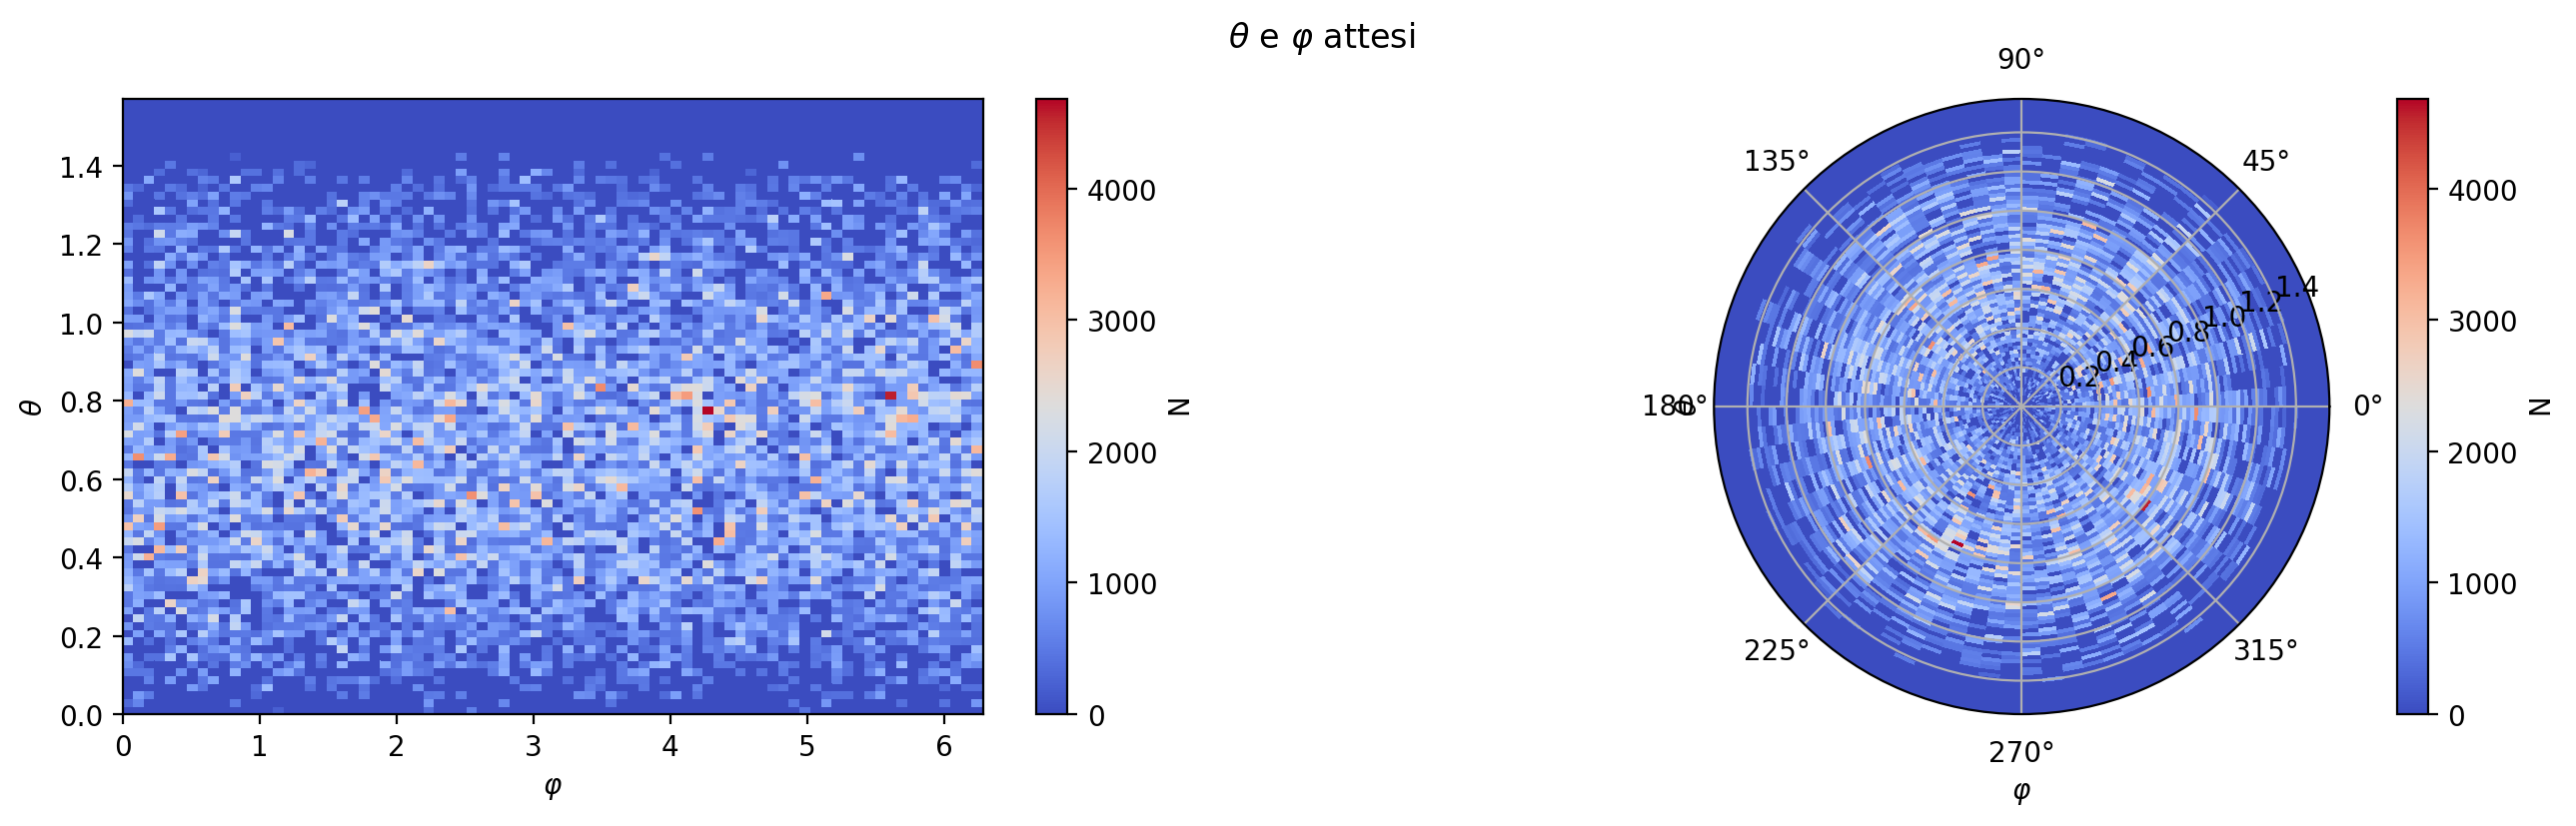

In [29]:
fig = plt.figure(figsize = (16, 4), dpi=200)
gs = gridspec.GridSpec(1, 9)
ax0 = fig.add_subplot(gs[:, :4])
ax1 = fig.add_subplot(gs[:, 4:], projection='polar')

c0 = ax0.pcolor(x, y, h_fs, cmap='coolwarm', vmin=0)
bar0 = fig.colorbar(c0, ax=ax0)
ax0.set(xlabel=r'$\varphi$', ylabel=r'$\theta$')
bar0.set_label(r'$\mathrm{N}$')

c1 = ax1.pcolor(x, y, h_fs, cmap='coolwarm', vmin=0)
bar1 = fig.colorbar(c1, ax=ax1)
ax1.set(xlabel=r'$\varphi$', ylabel=r'$\theta$')
bar1.set_label(r'$\mathrm{N}$')

plt.suptitle(r'$\theta$ e $\varphi$ attesi')
plt.show()

## Misura della trasmissione

In [31]:
T_th = np.divide(n_th_m, N_fs_th, out=np.zeros_like(N_fs_th), where=N_fs_th != 0)
T_ph = np.divide(n_ph_m, N_fs_ph, out=np.zeros_like(N_fs_ph), where=N_fs_ph != 0)
cl = 0.6827
alpha = 1 - cl
int_th = np.array([proportion.proportion_confint(n, N, alpha=alpha, method='beta') for n, N in zip(n_th_m[N_fs_th>0], N_fs_th[N_fs_th>0])])
int_ph = np.array([proportion.proportion_confint(n, N, alpha=alpha, method='beta') for n, N in zip(n_ph_m[N_fs_ph>0], N_fs_ph[N_fs_ph>0])])
err_th = np.array([T_th[N_fs_th>0]-int_th[:,0], int_th[:,1]-T_th[N_fs_th>0]])
err_ph = np.array([T_ph[N_fs_ph>0]-int_ph[:,0], int_ph[:,1]-T_ph[N_fs_ph>0]])

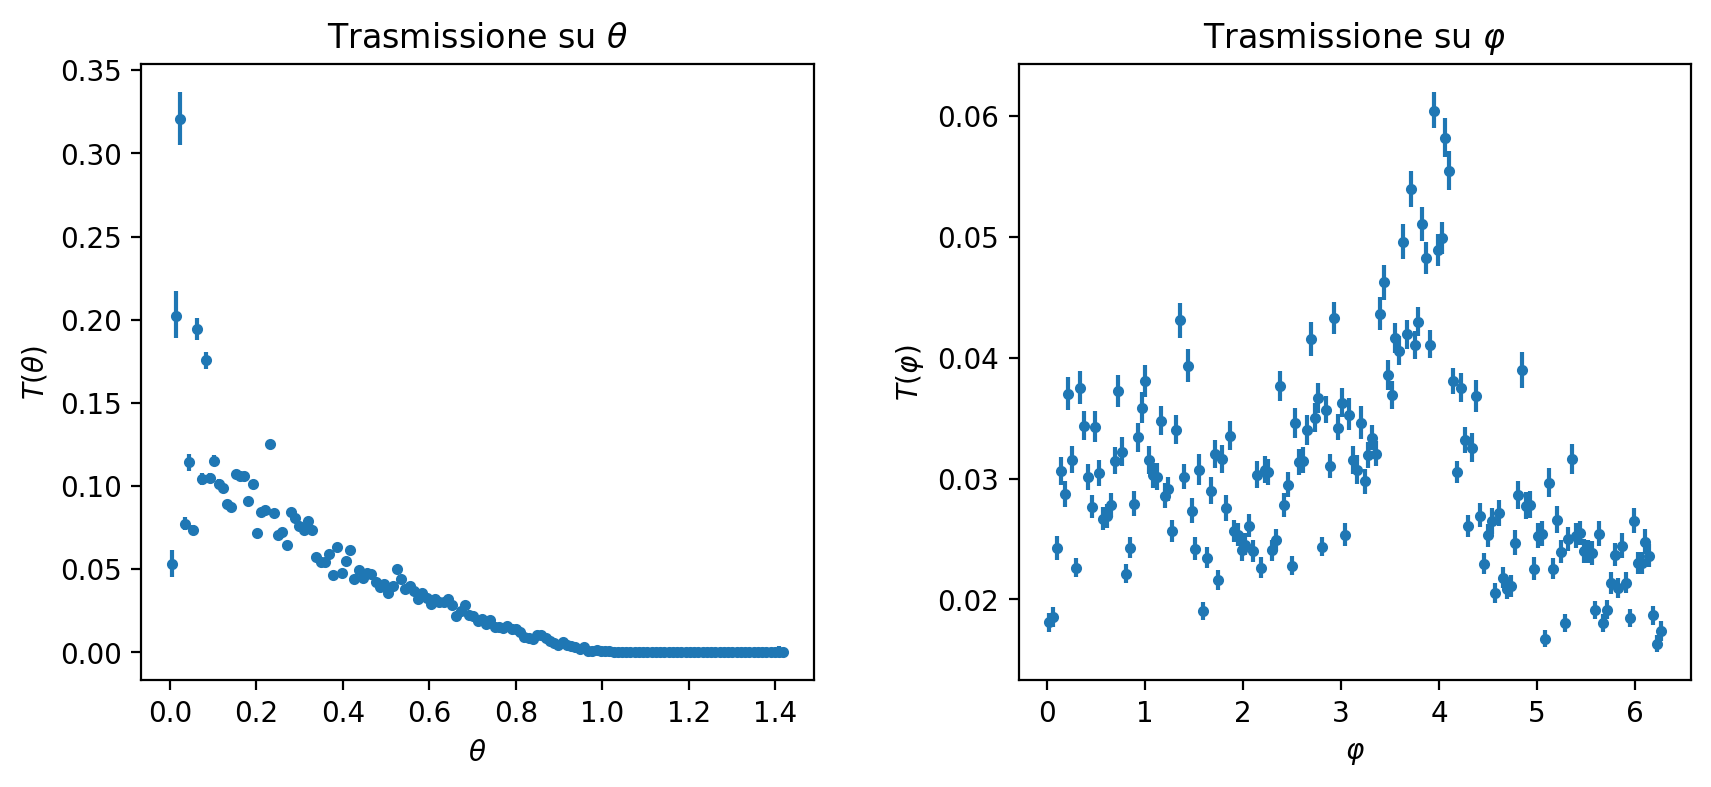

In [32]:
fig = plt.figure(figsize = (10, 4), dpi=200)
gs = gridspec.GridSpec(1, 9)
ax0 = fig.add_subplot(gs[:, :4])
ax1 = fig.add_subplot(gs[:, 5:])

ax0.errorbar(th1[N_fs_th>0], T_th[N_fs_th>0], err_th, fmt='.')
ax0.set(xlabel = r'$\theta$', ylabel = r'$T(\theta)$', title = r'Trasmissione su $\theta$')

ax1.errorbar(ph1[N_fs_ph>0], T_ph[N_fs_ph>0], err_ph, fmt='.')
ax1.set(xlabel = r'$\varphi$', ylabel = r'$T(\varphi)$', title = r'Trasmissione su $\varphi$')

plt.show()

In [33]:
T = np.divide(h_m, h_fs, out=np.zeros_like(h_fs), where=h_fs!=0)
T_lo, T_hi = [], []
for i in range(nbins2):
    his, los = [], [] 
    for j in range(nbins2):
        if h_fs[i,j]!=0:
            ci = proportion.proportion_confint(h_m[i,j], h_fs[i,j], alpha=alpha, method='beta')
            lo, hi = ci[0], ci[1]
        else:
            hi, lo = 0, 0
        his.append(hi)
        los.append(lo)
    T_lo.append(los)
    T_hi.append(his)
T_lo = np.array(T_lo)
T_hi = np.array(T_hi)

err_hi = T_hi - T
err_lo = T - T_lo

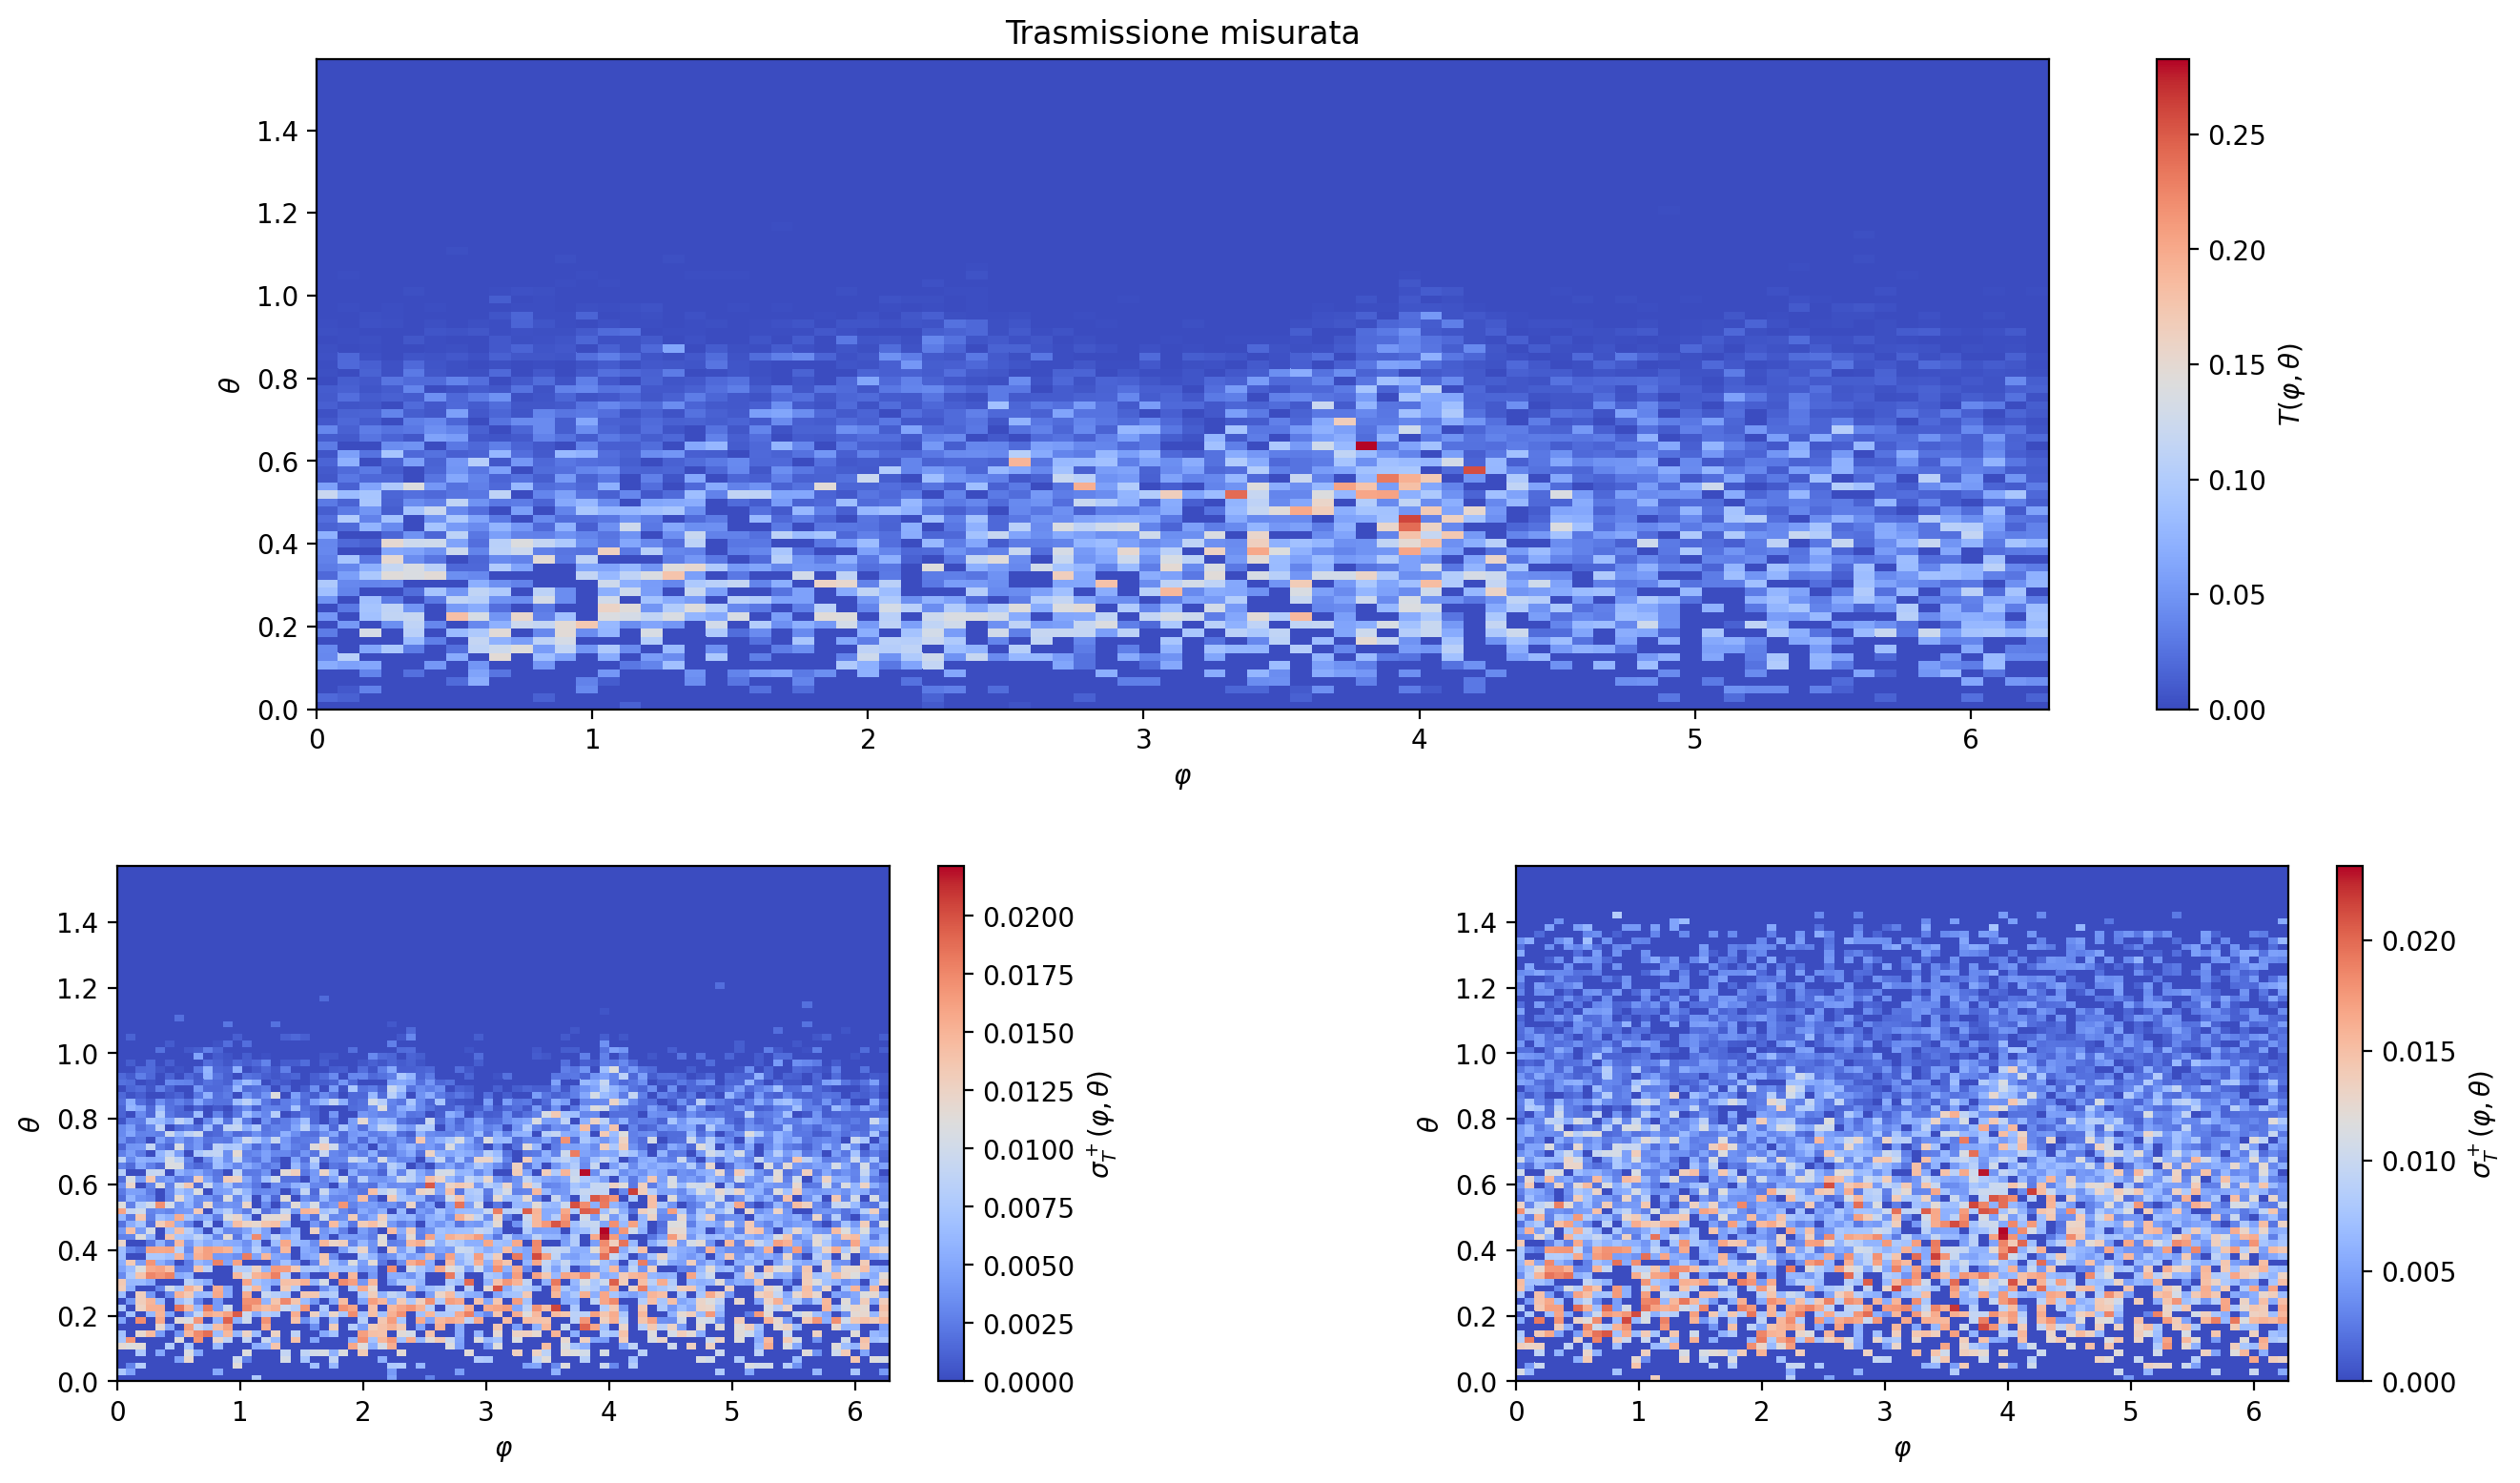

In [34]:
fig = plt.figure(figsize = (16, 9), dpi=200)
gs = gridspec.GridSpec(10, 12)
ax0 = fig.add_subplot(gs[:5, 1:])
ax1 = fig.add_subplot(gs[6:, :5])
ax2 = fig.add_subplot(gs[6:, 7:])

c0 = ax0.pcolor(x, y, T, cmap='coolwarm', vmin=0)
bar0 = fig.colorbar(c0, ax=ax0)
ax0.set(xlabel=r'$\varphi$', ylabel=r'$\theta$', title=r'Trasmissione misurata')
bar0.set_label(r'$T(\varphi, \theta)$')

c1 = ax1.pcolor(x, y, err_lo, cmap='coolwarm', vmin=0)
bar1 = fig.colorbar(c1, ax=ax1)
ax1.set(xlabel=r'$\varphi$', ylabel=r'$\theta$')
bar1.set_label(r'$\sigma_T^+(\varphi, \theta)$')

c2 = ax2.pcolor(x, y, err_hi, cmap='coolwarm', vmin=0)
bar2 = fig.colorbar(c2, ax=ax2)
ax2.set(xlabel=r'$\varphi$', ylabel=r'$\theta$')
bar2.set_label(r'$\sigma_T^+(\varphi, \theta)$')

plt.show()

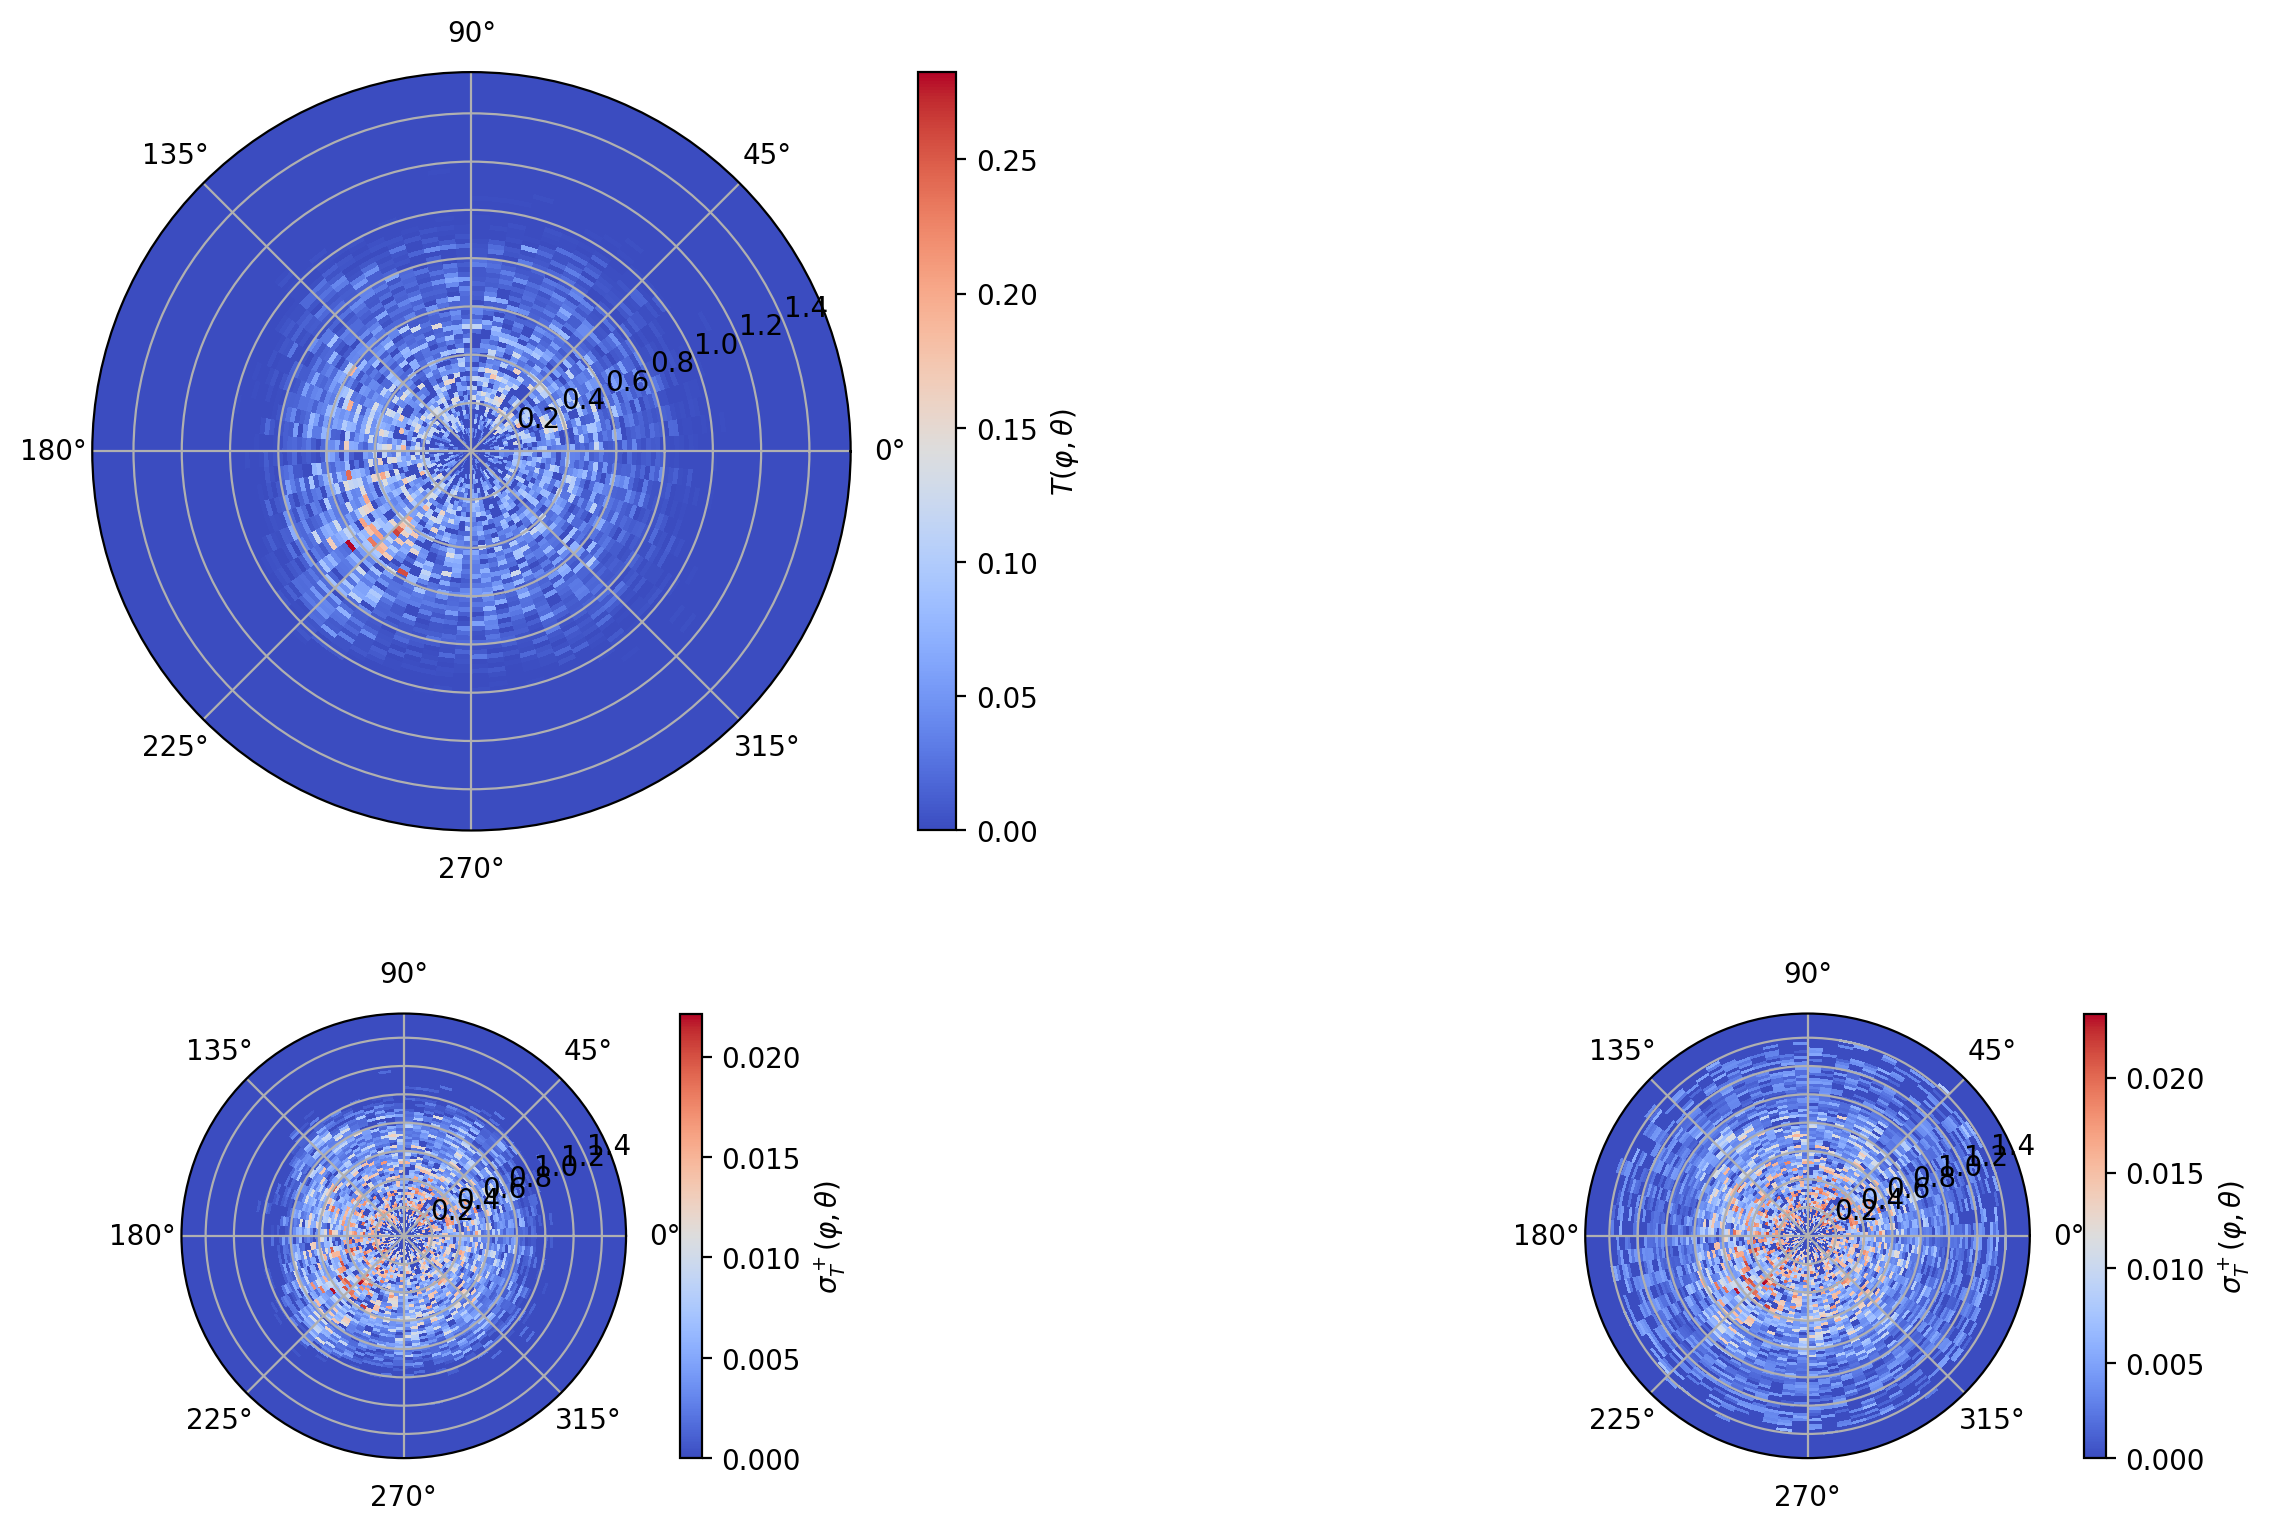

In [35]:
fig = plt.figure(figsize = (16, 9), dpi=200)
gs = gridspec.GridSpec(9, 9)
ax0 = fig.add_subplot(gs[:5, :5], projection='polar')
ax1 = fig.add_subplot(gs[6:, :4], projection='polar')
ax2 = fig.add_subplot(gs[6:, 5:], projection='polar')

c0 = ax0.pcolor(x, y, T, cmap='coolwarm', vmin=0)
bar0 = fig.colorbar(c0, ax=ax0)
bar0.set_label(r'$T(\varphi, \theta)$')

c1 = ax1.pcolor(x, y, err_lo, cmap='coolwarm', vmin=0)
bar1 = fig.colorbar(c1, ax=ax1)
bar1.set_label(r'$\sigma_T^+(\varphi, \theta)$')

c2 = ax2.pcolor(x, y, err_hi, cmap='coolwarm', vmin=0)
bar2 = fig.colorbar(c2, ax=ax2)
bar2.set_label(r'$\sigma_T^+(\varphi, \theta)$')

plt.show()

# Conclusioni

<img style="width: 700px" src="Tol1.png">

L'immagine mostra la sezione trasverale della stazione della metropolitana di Via Toledo. Confrontando con il grafico della trasmissione, riconosciamo la zona dei locali con le scale mobili ed il foro nel quadrante $180 - 270 ^{\circ}$ e per valori dell'angolo polare compresi tra $0.4 - 0.6 \, rad$ ($22.9 - 34.4 ^\circ$ circa).